In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.io import loadmat

import mne
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

mne.set_log_level('WARNING')
%matplotlib qt

In [2]:
def get_raw(eegData,bads=[]):
    
    #load raw EEG recordings
    raw = mne.io.read_raw_eeglab(eegData, preload=True)
    
    raw.filter(l_freq=0.5, h_freq=50) #filter
    
    # Set standard 10-20 montage
    raw.rename_channels({
    'PZ': 'Pz',
    'FZ': 'Fz',
    'C3': 'C4',
    'C4': 'C3',
    'AFZ': 'Cz'
})
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage)

    if bads:
        raw.info['bads']=bads
        raw.drop_channels(bads)

    raw.set_eeg_reference('average') #Common average referencing

    return raw

In [3]:
def get_epochs_by_amp(raw,trialLog):
    
    # Get events from annotations
    events, event_id = mne.events_from_annotations(raw)
    
    
    #load trialLogs.mat files
    log = loadmat(trialLog, squeeze_me=True)
    trial_data = log['trialData']
    trialData = pd.DataFrame(trial_data)
    
    print('numEvents = ',len(events), 'numTrials = ',trialData.shape[0],'\n')
    
    
    #extend amplitudes to match events
    events_per_trial = len(events)//trialData.shape[0]
    amps_expanded = []
    
    if '2AFC' in str(trialLog):
        events_per_trial//=2
        for i, row in trialData.iterrows():
            amp = row['amp']
            true_interval = row['trueInterval']
            
            if true_interval == 1:
                amps_expanded.extend([amp] * events_per_trial)
                amps_expanded.extend([0] * events_per_trial)
            else:
                amps_expanded.extend([0] * events_per_trial)
                amps_expanded.extend([amp] * events_per_trial)
    else:
        for i, row in trialData.iterrows():
            amp = row['amp']
            amps_expanded.extend([amp] * events_per_trial)
        
    
    amps_expanded = np.array(amps_expanded)
    
    #extract epochs -100ms before stim to 500ms afterstim
    tmin = -0.1
    tmax = 0.5 
    
    epochs = mne.Epochs(raw, events, event_id=event_id,
                        tmin=tmin, tmax=tmax,
                        baseline=None, preload=True)
    epochs.metadata = pd.DataFrame({'amp': amps_expanded})
    
    
    #extract epochs and averaged responses by amp
    epochs_by_amp = {}
    evokeds = {}
    
    for amp in np.unique(amps_expanded):
        epochs_by_amp[str(amp)] = epochs[epochs.metadata['amp'] == amp]
        evokeds[str(amp)] = epochs_by_amp[str(amp)].average()

    return epochs_by_amp,trialData

In [4]:
def plot_erp(epochs_by_amp, amp='all', ch_name='all'):
    """
    Plot ERP responses with scalp map.
    
    Parameters:
    - amp: 'all' or specific amplitude (e.g., 6.0)
    - ch_name: 'all' or specific channel (e.g., 'P4')
    """
    
    amps_sorted = sorted([float(a) for a in epochs_by_amp.keys()])
    if amp != 'all':
        amps_sorted = [float(a)]
    
    # Get one epochs object for channel info
    sample_epochs = epochs_by_amp[list(epochs_by_amp.keys())[0]]
    ch_names = sample_epochs.ch_names
    n_channels = len(ch_names)
    
    # 16 distinct colors
    colors = plt.cm.tab20(np.linspace(0, 1, n_channels))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 2]})
    
    # Left: scalp map
    if ch_name != 'all':
        ch_idx = ch_names.index(ch_name)
        mask = np.zeros(n_channels, dtype=bool)
        mask[ch_idx] = True
        mne.viz.plot_sensors(sample_epochs.info, axes=axes[0], show_names=True, 
                             ch_groups=[np.where(mask)[0]])
        axes[0].set_title(f'Channel: {ch_name}')
    else:
        mne.viz.plot_sensors(sample_epochs.info, axes=axes[0], show_names=True)
        axes[0].set_title('All channels')
    
    # Right: ERP plot
    for a in amps_sorted:
        amp_str = str(a)
        data = epochs_by_amp[amp_str].get_data()
        times_ms = epochs_by_amp[amp_str].times * 1000
        n_epochs = data.shape[0]
        data_uv = data * 1e6
        
        if ch_name != 'all':
            # One channel
            ch_idx = ch_names.index(ch_name)
            ch_data = data_uv[:, ch_idx, :]
            
            if amp != 'all':
                # One amp, one channel: show individual trials
                for i in range(n_epochs):
                    axes[1].plot(times_ms, ch_data[i, :], alpha=0.3, color='gray')
                axes[1].plot(times_ms, ch_data.mean(axis=0), color='red', linewidth=2, label='Average')
            else:
                # All amps, one channel
                axes[1].plot(times_ms, ch_data.mean(axis=0), label=f'{a} (n={n_epochs})')
        else:
            if amp != 'all':
                # One amp, all channels: plot each channel with distinct color
                for i, ch in enumerate(ch_names):
                    axes[1].plot(times_ms, data_uv[:, i, :].mean(axis=0), 
                                 color=colors[i], label=ch)
            else:
                # All amps, all channels: average across channels
                avg = data_uv.mean(axis=1).mean(axis=0)
                axes[1].plot(times_ms, avg, label=f'{a} (n={n_epochs})')
    
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_ylabel('Voltage (µV)')
    axes[1].set_title(f'Amp: {amp}, Channel: {ch_name}')
    axes[1].legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [5]:
eegData = 'baselineS001R03.set'
trialLog = 'baseline_ssERP_20260331_103331_trialLog.mat'
bad_channels = ['T7']

C:\Users\gia21\AppData\Local\Temp\ipykernel_28604\1766413829.py:4: RuntimeWarning: Data file name in EEG.data (AnteaS001R03.fdt) is incorrect, the file name must have changed on disk, using the correct file name (baselineS001R03.fdt).
  raw = mne.io.read_raw_eeglab(eegData, preload=True)


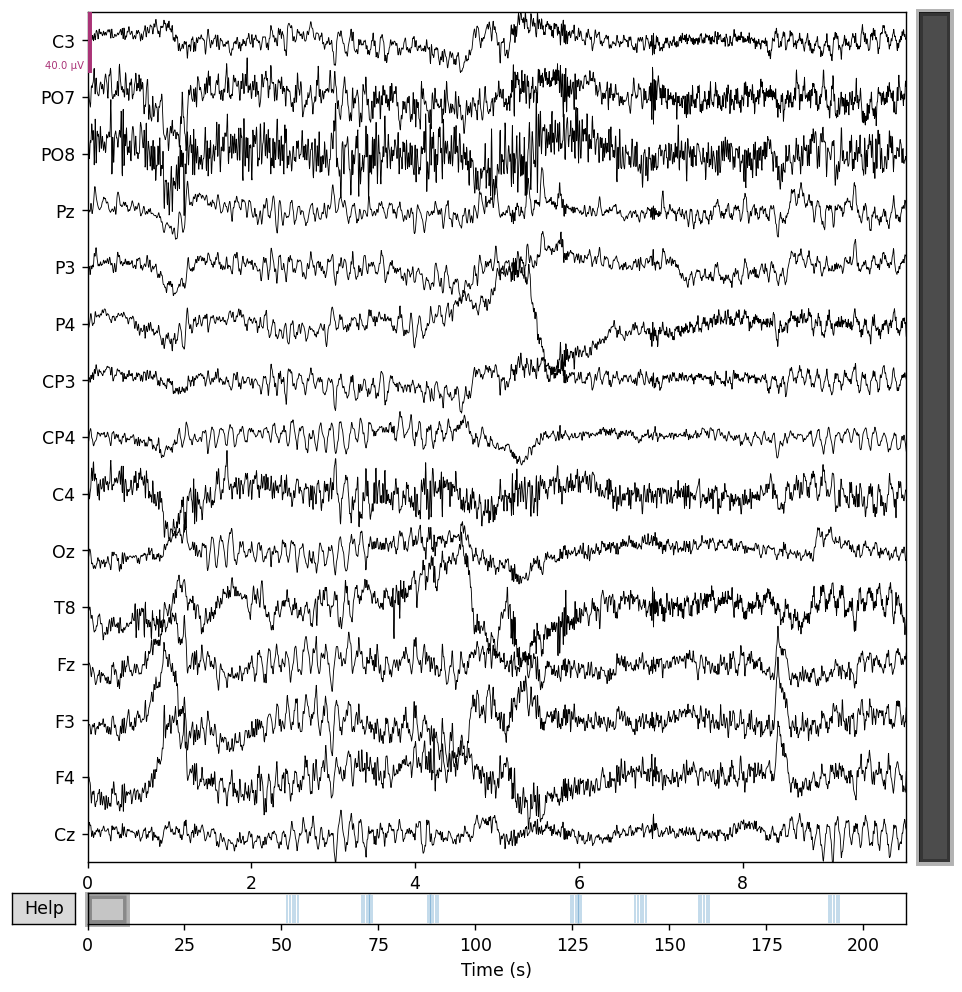

In [6]:
raw = get_raw(eegData,bad_channels)
mne.viz.plot_raw(raw)

In [7]:
epochs_by_amp,trialData = get_epochs_by_amp(raw,trialLog)
print('\nStim amplitudes (mA): ',list(trialData.amp))

numEvents =  35 numTrials =  7 


Stim amplitudes (mA):  [3.42, 1.71, 3.99, 2.85, 5.13, 4.56, 2.28]


# ICA

C:\Users\gia21\AppData\Local\Temp\ipykernel_28604\3862512671.py:12: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  high_amp_epochs = mne.concatenate_epochs([epochs_by_amp[k] for k in high_amps])
C:\Users\gia21\AppData\Local\anaconda3\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


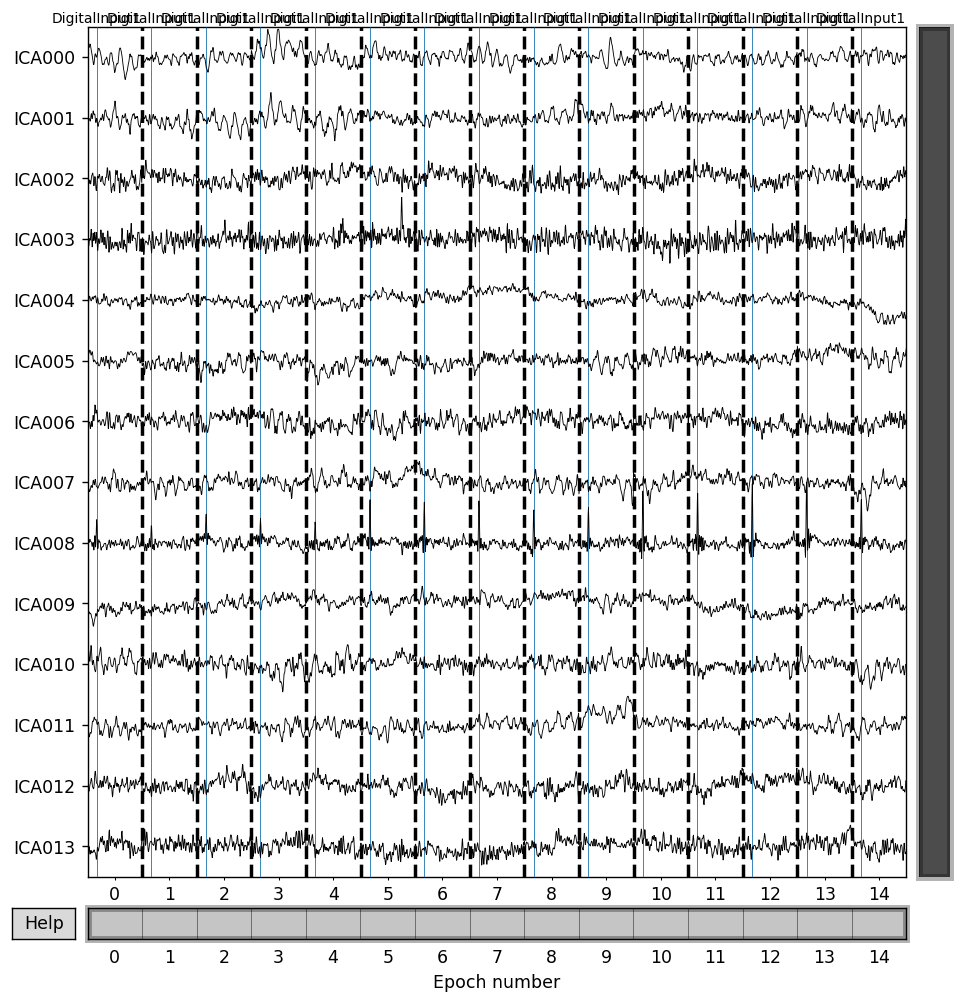

In [8]:
threshold = '3.42'  # mA
low_amps=[]
high_amps = []
for amp in epochs_by_amp.keys():
    if float(amp)<float(threshold):
        low_amps.append(amp)
    elif float(amp)>float(threshold):
        high_amps.append(amp)


# Concatenate high amplitude epochs
high_amp_epochs = mne.concatenate_epochs([epochs_by_amp[k] for k in high_amps])

# Fit on high amplitude epochs
ica = mne.preprocessing.ICA(
    n_components=0.999,
    fit_params={'tol': 0.01},
    random_state=42
)
ica.fit(high_amp_epochs)
ica.plot_sources(high_amp_epochs)

In [9]:
exclude_ics =[8]

ica.plot_properties(high_amp_epochs, picks=exclude_ics)

[<Figure size 875x750 with 6 Axes>]

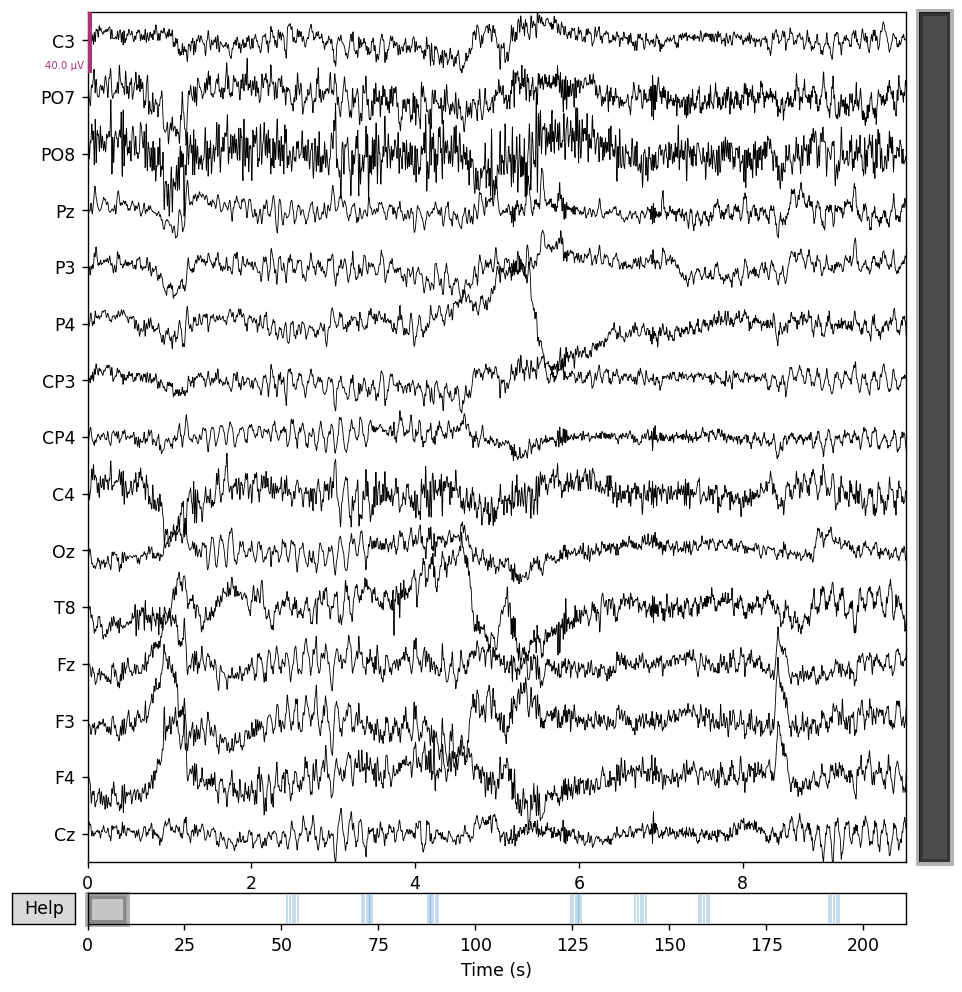

In [10]:
ica.exclude = exclude_ics # artifact components
# Apply ICA to raw, then re-extract all epochs
raw_clean = ica.apply(raw.copy())
mne.viz.plot_raw(raw_clean)

In [11]:
#get cleaned epochs
epochs_by_amp_clean, _ = get_epochs_by_amp(raw_clean, trialLog)

numEvents =  35 numTrials =  7 



# Data Viz

In [12]:
print(raw.ch_names)
print(epochs_by_amp_clean.keys())

['C3', 'PO7', 'PO8', 'Pz', 'P3', 'P4', 'CP3', 'CP4', 'C4', 'Oz', 'T8', 'Fz', 'F3', 'F4', 'Cz']
dict_keys(['1.71', '2.28', '2.85', '3.42', '3.99', '4.56', '5.13'])


In [13]:
# for ch_name in raw.ch_names:
#     plot_erp(epochs_by_amp_clean, ch_name=ch_name)

In [14]:
# plot_erp(epochs_by_amp_clean)

# CSP + LDA

In [15]:
low_amps_epochs = mne.concatenate_epochs([epochs_by_amp_clean[k] for k in low_amps])
high_amps_epochs = mne.concatenate_epochs([epochs_by_amp_clean[k] for k in high_amps])

subthresh_data = low_amps_epochs.get_data()
thresh_data = epochs_by_amp_clean[threshold].get_data()
suprathresh_data = high_amps_epochs.get_data()

X = np.concatenate([thresh_data, subthresh_data], axis=0)
y = np.array([1]*len(thresh_data) + [0]*len(subthresh_data))

C:\Users\gia21\AppData\Local\Temp\ipykernel_28604\2025113959.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  low_amps_epochs = mne.concatenate_epochs([epochs_by_amp_clean[k] for k in low_amps])
C:\Users\gia21\AppData\Local\Temp\ipykernel_28604\2025113959.py:2: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  high_amps_epochs = mne.concatenate_epochs([epochs_by_amp_clean[k] for k in high_amps])


In [16]:
# Pipeline
n_components = min(4, X.shape[1] // 2)
csp = CSP(n_components=n_components, reg=0.1, log=True, norm_trace=True)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
pipeline = Pipeline([('csp', csp), ('lda', lda)])

# Cross-validation
y_true = y.copy()  # preserve original
cv = StratifiedKFold(n_splits=5, shuffle=False)
real_scores = cross_val_score(pipeline, X, y_true, cv=cv, scoring='roc_auc')
real_auc = real_scores.mean()

# Permutation test

mean_AUCs = []
np.random.seed(42)
for i in range(100):
    y_perm = np.random.permutation(y_true)
    scores = cross_val_score(pipeline, X, y_perm, cv=cv, scoring='roc_auc')
    mean_AUCs.append(scores.mean())

p_value = (np.array(mean_AUCs) >= real_auc).mean()

#Histogram plot
bins = 15

plt.figure()
ax=sns.histplot(data=mean_AUCs, bins=bins, kde=True)
ax.axvline(x=real_auc, ymin=0, ymax=1, color="red", linestyle="--", label=f'Real AUC = {real_auc:.3f}')
ax.legend()
ax.set_title(f'Permutation Test (n=100, p={p_value:.2f})')
ax.set_xlabel('AUC')
plt.show()

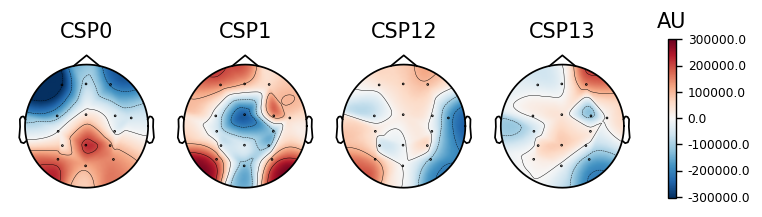

In [17]:
# Visualize common spatial patterns
pipeline.fit(X, y)
csp_fitted = pipeline.named_steps['csp']
csp_fitted.plot_patterns(low_amps_epochs.info, ch_type='eeg', components=[0, 1, 12, 13])